<a href="https://colab.research.google.com/github/sabawoonrahman942-netizen/Face-Recognition-OpenCV-/blob/main/face_recognition_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import cv2
import os
import numpy as np
from google.colab.patches import cv2_imshow

drive.mount('/content/drive')

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

base_path = '/content/drive/MyDrive/FaceProject/'
train_path = base_path + 'oyuncu_yuzleri/'
test_path = base_path + 'test_images/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

def yuzleri_egit(train_path):
    yuzler = []
    isimler = []

    for oyuncu_adi in os.listdir(train_path):
        oyuncu_klasoru = os.path.join(train_path, oyuncu_adi)

        if os.path.isdir(oyuncu_klasoru):
            for resim_adi in os.listdir(oyuncu_klasoru):
                resim_yolu = os.path.join(oyuncu_klasoru, resim_adi)


                resim = cv2.imread(resim_yolu)
                if resim is None: continue

                gri = cv2.cvtColor(resim, cv2.COLOR_BGR2GRAY)


                tespit_edilen_yuzler = face_cascade.detectMultiScale(gri, 1.3, 5)

                for (x, y, w, h) in tespit_edilen_yuzler:

                    yuz_bolgesi = gri[y:y+h, x:x+w]
                    yuzler.append(yuz_bolgesi)
                    isimler.append(oyuncu_adi)

    return yuzler, isimler
kayitli_yuzler, kayitli_isimler = yuzleri_egit(train_path)

print(f"Toplam {len(set(kayitli_isimler))} oyuncu ve {len(kayitli_yuzler)} adet yüz başarıyla sisteme yüklendi.")

Toplam 10 oyuncu ve 10 adet yüz başarıyla sisteme yüklendi.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sistem eğitiliyor, lütfen bekleyin...
Eğitim tamamlandı. 10 farklı oyuncu için 10 yüz verisi yüklendi.

--- Rastgele Test ---


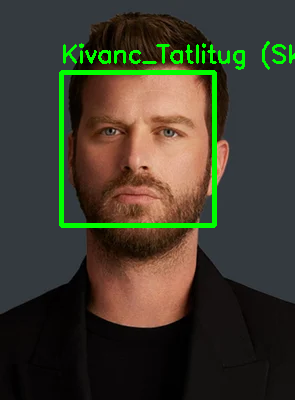

In [7]:
import cv2
import os
import numpy as np
import random
from google.colab.patches import cv2_imshow
from google.colab import drive

drive.mount('/content/drive')


base_path = '/content/drive/MyDrive/FaceProject/'
train_path = os.path.join(base_path, 'oyuncu_yuzleri/')
test_path = os.path.join(base_path, 'test_images/')


face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def yuzleri_egit(train_path):
    yuzler = []
    isimler = []

    for oyuncu_adi in os.listdir(train_path):
        oyuncu_klasoru = os.path.join(train_path, oyuncu_adi)
        if os.path.isdir(oyuncu_klasoru):
            for resim_adi in os.listdir(oyuncu_klasoru):
                resim_yolu = os.path.join(oyuncu_klasoru, resim_adi)
                resim = cv2.imread(resim_yolu)
                if resim is None: continue

                gri = cv2.cvtColor(resim, cv2.COLOR_BGR2GRAY)
                tespitler = face_cascade.detectMultiScale(gri, 1.3, 5)

                for (x, y, w, h) in tespitler:

                    yuz_kesit = cv2.resize(gri[y:y+h, x:x+w], (100, 100))
                    yuzler.append(yuz_kesit)
                    isimler.append(oyuncu_adi)

    return yuzler, isimler

print("Sistem eğitiliyor, lütfen bekleyin...")
kayitli_yuzler, kayitli_isimler = yuzleri_egit(train_path)
print(f"Eğitim tamamlandı. {len(set(kayitli_isimler))} farklı oyuncu için {len(kayitli_yuzler)} yüz verisi yüklendi.")

def yuz_tani_ve_goster(test_resim_adi):
    img_path = os.path.join(test_path, test_resim_adi)
    img = cv2.imread(img_path)

    if img is None:
        print(f"Hata: {test_resim_adi} bulunamadı!")
        return

    gri = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    tespit_edilenler = face_cascade.detectMultiScale(gri, 1.2, 5)

    for (x, y, w, h) in tespit_edilenler:
        test_yuz = cv2.resize(gri[y:y+h, x:x+w], (100, 100))

        en_iyi_skor = float('inf')
        tahmin_isim = "Kayitli Degil"


        for i, kayitli_yuz in enumerate(kayitli_yuzler):
            skor = np.sum((test_yuz.astype("float") - kayitli_yuz.astype("float")) ** 2)
            skor = skor / float(test_yuz.shape[0] * test_yuz.shape[1])


            if skor < en_iyi_skor and skor < 5000:
                en_iyi_skor = skor
                tahmin_isim = kayitli_isimler[i]


        renk = (0, 255, 0) if tahmin_isim != "Kayitli Degil" else (0, 0, 255)


        if tahmin_isim != "Kayitli Degil":
            etiket = f"{tahmin_isim} (Skor: {int(en_iyi_skor)})"
        else:
            etiket = "Kayitli Degil"

        cv2.rectangle(img, (x, y), (x+w, y+h), renk, 3)
        cv2.putText(img, etiket, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, renk, 2)

    cv2_imshow(img)

print("\n--- Rastgele Test ---")
test_listesi = [f for f in os.listdir(test_path) if f.endswith((".jpg", ".png", ".jpeg"))]
if test_listesi:
    secilen = random.choice(test_listesi)
    yuz_tani_ve_goster(secilen)

